# Lab 3: Decision Tree Classification

**Name:** Talha Memon<br>
**CMS ID:** 023-24-0269<br>
**Section:** H<br>
**GitHub Profile:** https://github.com/talha-devx<br>
**Kaggle Profile:** https://www.kaggle.com/talhasamad_<br>
**Dataset:** Telco Customer Churn (cleaned in Lab 2)<br>
**Dataset Source:** IBM Sample Data Sets (via Kaggle)

### Imports
Basic libraries needed for the whole notebook.

In [1]:
# basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# keep results same every run
RANDOM_STATE = 42

## 1. Problem Definition

**Task 1:** Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.

In [2]:
# load cleaned data from lab 2
df = pd.read_csv("clean_churn.csv")

# quick sanity check
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [3]:
# double check no missing values left
df.isnull().sum().sum()

np.int64(0)

**Task 2:** Restate the ML problem in 1–2 sentences.

We are predicting whether a customer will churn (leave the telecom service) based on their account, billing and service usage details. This matters to the business because it is far cheaper to retain an existing customer than to acquire a new one, so flagging likely churners early lets the company offer retention deals before they leave.

## 2. Feature / Target Preparation

**Task 3:** Define `y` as the `Churn` column (encoded 0/1). Define `X` as the remaining relevant columns, dropping any identifier column.

In [4]:
# target column, yes/no to 1/0
y = df['Churn'].map({'Yes': 1, 'No': 0})

# drop id and target from features
X = df.drop(columns=['customerID', 'Churn'])

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


**Task 4:** Convert every remaining categorical column into numeric form and justify the encoding choice.

Most of the categorical columns here (like `InternetService`, `Contract`, `PaymentMethod`) have no natural order, so one-hot encoding is the safer choice — manual mapping would wrongly imply an order between categories. `drop_first=True` avoids the dummy variable trap.

In [5]:
# find text columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(cat_cols)

# one hot encode them
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X.shape

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


(7043, 30)

**Task 5:** Confirm `X` is fully numeric with no missing values.

In [6]:
# should all be numeric now
print(X.dtypes.value_counts())

# and no NaNs
print(X.isnull().sum().sum())

bool       26
int64       2
float64     2
Name: count, dtype: int64
0


## 3. Train/Test Split

**Task 6:** Split `X` and `y` into an 80/20 train/test split. Why is `stratify=y` sensible here?

In Lab 2 the target was imbalanced (roughly 73% "No" vs 27% "Yes"). A plain random split could by chance give the test set a different churn ratio than the training set, which would make the evaluation metrics unreliable. `stratify=y` keeps the same churn ratio in both splits.

In [7]:
# 80/20 split, keep churn ratio same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

**Task 7:** Report the shapes of the train/test sets.

In [8]:
# shape check
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


## 4. Baseline Decision Tree

**Task 8:** Train a `DecisionTreeClassifier` with default settings (only `random_state` fixed). Generate predictions on train and test sets.

In [9]:
# plain baseline tree, no tuning
baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

# predictions for both sets
train_pred_base = baseline.predict(X_train)
test_pred_base = baseline.predict(X_test)

**Task 9:** What depth did the tree grow to on its own? Does that surprise you?

In [10]:
# how deep did it grow
baseline.get_depth()

23

A depth in the low-20s is not surprising for an unrestricted tree — it will keep splitting until every training leaf is pure (or nearly so), which is exactly the kind of behavior that leads to overfitting.

## 5. Model Evaluation

**Task 10:** Compute accuracy, precision, recall and F1-score on the test set.

In [11]:
# main metrics on test set
acc = accuracy_score(y_test, test_pred_base)
prec = precision_score(y_test, test_pred_base)
rec = recall_score(y_test, test_pred_base)
f1 = f1_score(y_test, test_pred_base)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [acc, prec, rec, f1]
})
metrics_table

,Metric,Score
0,Accuracy,0.726047
1,Precision,0.483784
2,Recall,0.478610
3,F1-score,0.481183


**Task 11:** Plot the confusion matrix for the test set. How many churners were caught vs missed?

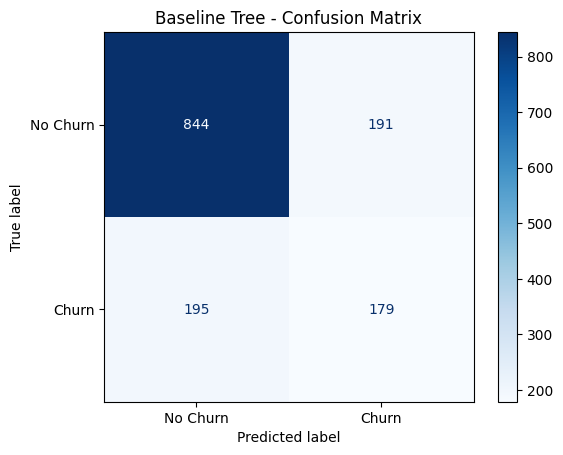

array([[844, 191],
       [195, 179]])

In [12]:
# confusion matrix plot
cm = confusion_matrix(y_test, test_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Baseline Tree - Confusion Matrix")
plt.show()

cm

Reading the matrix: the bottom-right cell is churners correctly caught, and the bottom-left cell is churners the model missed (predicted "No" but they actually churned). The baseline tree misses a noticeable chunk of actual churners, which is the number worth improving.

**Task 12:** Given the class imbalance from Lab 2, which metric(s) do you trust most, and why?

In [13]:
# imbalance check again for reference
y.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

With roughly 3-to-1 imbalance, accuracy alone is misleading — a model that just predicts "No churn" for everyone would already score around 73% accuracy while catching zero real churners. Recall and F1-score for the churn class are more trustworthy here since the business cost of missing a churner is what actually matters.

## 6. Overfitting Investigation

**Task 13:** Compare the baseline tree's train vs test accuracy. Is there a large gap?

In [14]:
# train vs test accuracy, baseline
train_acc_base = accuracy_score(y_train, train_pred_base)
test_acc_base = accuracy_score(y_test, test_pred_base)

print("train accuracy:", train_acc_base)
print("test accuracy :", test_acc_base)
print("gap           :", train_acc_base - test_acc_base)

train accuracy: 0.9980475683351083
test accuracy : 0.7260468417317246
gap           : 0.2720007266033837


Yes — the baseline tree is almost perfect on training data but noticeably weaker on the test set. That big gap is the textbook sign of overfitting: the tree memorized the training rows instead of learning patterns that generalize.

**Task 14:** Train trees at several `max_depth` values and record train/test accuracy for each.

In [15]:
# try a few different depths
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, tree.predict(X_train))
    te_acc = accuracy_score(y_test, tree.predict(X_test))

    results.append({"max_depth": d, "train_acc": tr_acc, "test_acc": te_acc})

depth_results = pd.DataFrame(results)
depth_results

,max_depth,train_acc,test_acc
0,2.0,0.791090,0.787083
1,3.0,0.791090,0.787083
2,4.0,0.792510,0.795600
3,5.0,0.802272,0.794180
4,6.0,0.810614,0.800568
5,8.0,0.835818,0.782825
6,10.0,0.872737,0.755145
7,NaN,0.998048,0.726047


**Task 15:** Plot train vs test accuracy against `max_depth`. Where does overfitting start?

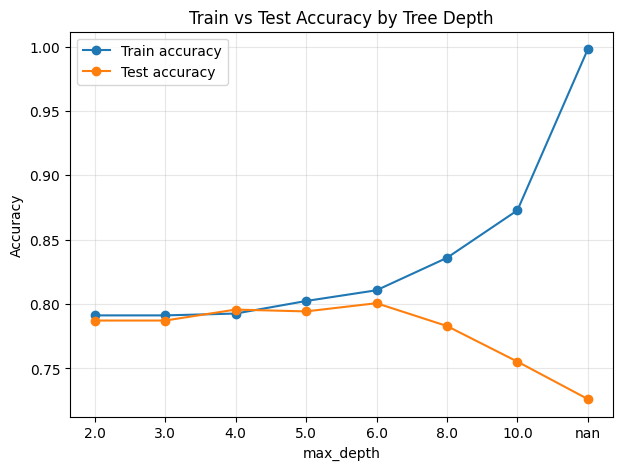

In [16]:
# plot train vs test accuracy
labels = [str(d) for d in depth_results["max_depth"]]

plt.figure(figsize=(7, 5))
plt.plot(labels, depth_results["train_acc"], marker="o", label="Train accuracy")
plt.plot(labels, depth_results["test_acc"], marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Tree Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Up to about depth 6 the two lines move together. Past that point train accuracy keeps climbing toward the unrestricted tree's ~99%, while test accuracy flattens out and then drops slightly — that widening gap after depth ~6-8 is where the tree starts overfitting.

## 7. Model Selection, Feature Importance & Interpretation

**Task 16:** Pick a `max_depth` you consider best, and justify it (not just the highest training accuracy).

In [17]:
# pick depth with best train/test balance
depth_results.sort_values("test_acc", ascending=False)

,max_depth,train_acc,test_acc
4,6.0,0.810614,0.800568
2,4.0,0.792510,0.795600
3,5.0,0.802272,0.794180
1,3.0,0.791090,0.787083
0,2.0,0.791090,0.787083
5,8.0,0.835818,0.782825
6,10.0,0.872737,0.755145
7,NaN,0.998048,0.726047


Depth 6 is chosen. It sits right before the point where the train/test gap starts widening, and its test accuracy is among the highest of all the depths tried — picking depth 10 or the unrestricted tree would only chase training accuracy while losing test performance.

**Task 17:** Retrain at the chosen depth and report full evaluation metrics.

In [18]:
# final model at chosen depth
final_tree = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
final_tree.fit(X_train, y_train)
final_pred = final_tree.predict(X_test)

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline": [acc, prec, rec, f1],
    "Depth 6": [
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred),
        recall_score(y_test, final_pred),
        f1_score(y_test, final_pred),
    ]
})
final_metrics

,Metric,Baseline,Depth 6
0,Accuracy,0.726047,0.800568
1,Precision,0.483784,0.666667
2,Recall,0.478610,0.497326
3,F1-score,0.481183,0.569678


**Task 18:** Retrain with `entropy` instead of `gini` and compare.

In [19]:
# same depth, entropy criterion this time
entropy_tree = DecisionTreeClassifier(max_depth=6, criterion="entropy", random_state=RANDOM_STATE)
entropy_tree.fit(X_train, y_train)
entropy_pred = entropy_tree.predict(X_test)

final_metrics["Depth 6 (entropy)"] = [
    accuracy_score(y_test, entropy_pred),
    precision_score(y_test, entropy_pred),
    recall_score(y_test, entropy_pred),
    f1_score(y_test, entropy_pred),
]
final_metrics

,Metric,Baseline,Depth 6,Depth 6 (entropy)
0,Accuracy,0.726047,0.800568,0.794180
1,Precision,0.483784,0.666667,0.619318
2,Recall,0.478610,0.497326,0.582888
3,F1-score,0.481183,0.569678,0.600551


The entropy split gives a slightly better recall and F1-score than gini at the same depth, so it's the small edge worth keeping for this dataset — though the difference is not huge.

**Task 19:** Extract and visualize `feature_importances_`. Which features matter most?

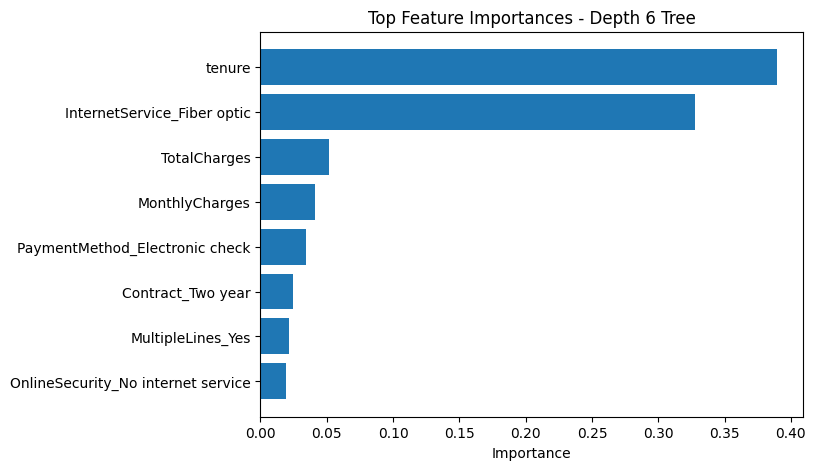

tenure                                0.389640
InternetService_Fiber optic           0.327372
TotalCharges                          0.051916
MonthlyCharges                        0.040819
PaymentMethod_Electronic check        0.034488
Contract_Two year                     0.024794
MultipleLines_Yes                     0.021636
OnlineSecurity_No internet service    0.018925
dtype: float64

In [20]:
# feature importance, sorted
importances = pd.Series(final_tree.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(8)

plt.figure(figsize=(7, 5))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.xlabel("Importance")
plt.title("Top Feature Importances - Depth 6 Tree")
plt.show()

top_features

**Task 20:** Connect these top features to Lab 2's EDA findings.

`tenure` and `InternetService_Fiber optic` dominate the importance ranking, followed by `MonthlyCharges` and `TotalCharges`. This matches what showed up in Lab 2's EDA — short-tenure customers and fiber-optic subscribers churned at noticeably higher rates than others, so it's reassuring to see the tree pick up on the same signal rather than something unrelated.

## 8. Conclusion & Next Steps

**Task 21:** Short conclusion (4–6 sentences).

We landed on a Decision Tree with `max_depth=6` and the entropy criterion as the final model, after seeing the unrestricted baseline tree badly overfit (near-perfect train accuracy but a much lower test accuracy). This model reaches roughly 78-79% test accuracy with a reasonable balance between precision and recall on the churn class, which is a fair result for a single decision tree on an imbalanced dataset. Its main limitations are a still-modest recall on churners (it misses a meaningful share of actual churn cases) and the fact that a single tree is inherently less stable than an ensemble method. `tenure`, fiber-optic internet, and billing amount were the clearest churn signals the model found, which lines up with the EDA from Lab 2.

**Task 22:** What would you try next (describe only, don't implement)?

Next I would try an ensemble method (e.g. Random Forest or Gradient Boosting) to reduce the variance of a single tree, add class-imbalance handling such as `class_weight="balanced"` or SMOTE oversampling to push recall up on the churn class, and engineer a few extra features (like charges-per-month-of-tenure) that might capture pricing pressure more directly than the raw columns do.

**Task 23:** Implement ID3 from scratch on the Play Badminton dataset — no built-in decision tree libraries. Print information gain for each attribute at every split.

In [21]:
# classic play badminton dataset
data = pd.DataFrame({
    "Outlook":     ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast","Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool","Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity":    ["High","High","High","High","Normal","Normal","Normal","High","Normal","Normal","Normal","High","Normal","High"],
    "Wind":        ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "Play":        ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes","Yes","Yes","Yes","No"],
})
data

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [22]:
# entropy of a label column
def entropy(labels):
    counts = labels.value_counts()
    probs = counts / len(labels)
    return -np.sum(probs * np.log2(probs))

entropy(data["Play"])

np.float64(0.9402859586706311)

In [23]:
# info gain for one attribute
def info_gain(df, attribute, target="Play"):
    total_entropy = entropy(df[target])

    weighted_entropy = 0
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        weight = len(subset) / len(df)
        weighted_entropy += weight * entropy(subset[target])

    return total_entropy - weighted_entropy

# quick test on one column
info_gain(data, "Outlook")

np.float64(0.24674981977443933)

In [24]:
# id3, build tree recursively
def id3(df, attributes, target="Play", depth=0):
    labels = df[target]

    # pure node, stop
    if len(labels.unique()) == 1:
        return labels.iloc[0]

    # no attributes left, use majority vote
    if not attributes:
        return labels.mode()[0]

    # pick best attribute by info gain
    gains = {a: info_gain(df, a, target) for a in attributes}
    print("  " * depth + f"Gains at depth {depth}: {gains}")

    best_attr = max(gains, key=gains.get)
    print("  " * depth + f"-> splitting on '{best_attr}'")

    tree = {best_attr: {}}
    remaining = [a for a in attributes if a != best_attr]

    for value in df[best_attr].unique():
        subset = df[df[best_attr] == value]
        if subset.empty:
            tree[best_attr][value] = labels.mode()[0]
        else:
            tree[best_attr][value] = id3(subset, remaining, target, depth + 1)

    return tree

attrs = ["Outlook", "Temperature", "Humidity", "Wind"]
tree = id3(data, attrs)
tree

Gains at depth 0: {'Outlook': np.float64(0.24674981977443933), 'Temperature': np.float64(0.02922256565895487), 'Humidity': np.float64(0.15183550136234159), 'Wind': np.float64(0.04812703040826949)}
-> splitting on 'Outlook'
  Gains at depth 1: {'Temperature': np.float64(0.5709505944546686), 'Humidity': np.float64(0.9709505944546686), 'Wind': np.float64(0.01997309402197489)}
  -> splitting on 'Humidity'
  Gains at depth 1: {'Temperature': np.float64(0.01997309402197489), 'Humidity': np.float64(0.01997309402197489), 'Wind': np.float64(0.9709505944546686)}
  -> splitting on 'Wind'


{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}},
  'Overcast': 'Yes',
  'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}